# Week 2: ERA5 Climate Trends in Vaud, Switzerland

This notebook analyzes monthly mean 2m temperature data for the Vaud region using a locally downloaded NetCDF file (`data/ERA5_monthly_temp.nc`).

## Step 1: Load dataset in xarray

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load NetCDF file from local directory
ds = xr.open_dataset("../data/ERA5_monthly_temp.nc")
ds.info()

xarray.Dataset {
dimensions:
	valid_time = 1032 ;
	latitude = 3 ;
	longitude = 6 ;

variables:
	float32 t2m(valid_time, latitude, longitude) ;
		t2m:GRIB_paramId = 167 ;
		t2m:GRIB_dataType = an ;
		t2m:GRIB_numberOfPoints = 18 ;
		t2m:GRIB_typeOfLevel = surface ;
		t2m:GRIB_stepUnits = 1 ;
		t2m:GRIB_stepType = avgua ;
		t2m:GRIB_gridType = regular_ll ;
		t2m:GRIB_uvRelativeToGrid = 0 ;
		t2m:GRIB_NV = 0 ;
		t2m:GRIB_Nx = 6 ;
		t2m:GRIB_Ny = 3 ;
		t2m:GRIB_cfName = unknown ;
		t2m:GRIB_cfVarName = t2m ;
		t2m:GRIB_gridDefinitionDescription = Latitude/Longitude Grid ;
		t2m:GRIB_iDirectionIncrementInDegrees = 0.25 ;
		t2m:GRIB_iScansNegatively = 0 ;
		t2m:GRIB_jDirectionIncrementInDegrees = 0.25 ;
		t2m:GRIB_jPointsAreConsecutive = 0 ;
		t2m:GRIB_jScansPositively = 0 ;
		t2m:GRIB_latitudeOfFirstGridPointInDegrees = 46.58 ;
		t2m:GRIB_latitudeOfLastGridPointInDegrees = 46.08 ;
		t2m:GRIB_longitudeOfFirstGridPointInDegrees = 5.94 ;
		t2m:GRIB_longitudeOfLastGridPointInDegrees = 7.19 ;
		

## Step 2: Regional mean time series in Vaud

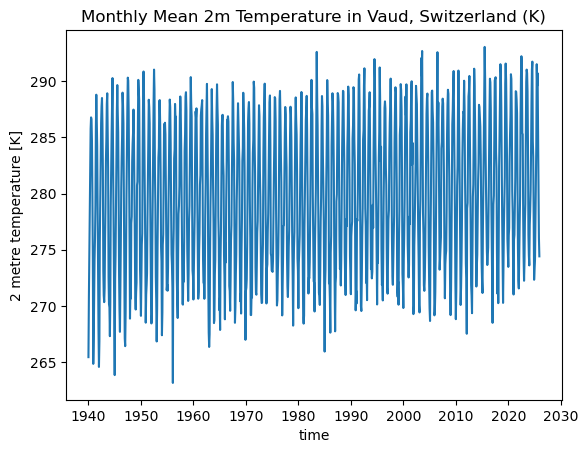

In [8]:
ts_vaud = ds['t2m'].mean(dim=['latitude','longitude'])
ts_vaud.plot()
plt.title("Monthly Mean 2m Temperature in Vaud, Switzerland (K)")
plt.show()

## Step 3: Calculate anomalies in relation to 1981–2010 baseline

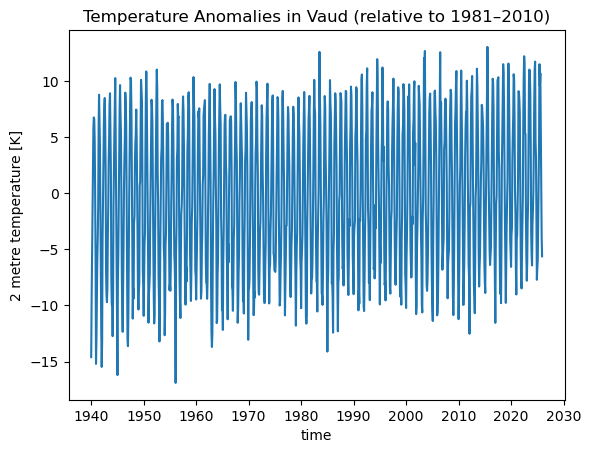

In [10]:
baseline_vaud = ts_vaud.sel(valid_time=slice("1981-01-01", "2010-12-31")).mean()
anomalies_vaud = ts_vaud - baseline_vaud
anomalies_vaud.plot()
plt.title("Temperature Anomalies in Vaud (relative to 1981–2010)")
plt.show()

## Step 4: Seasonal maps in version 1
This first version shows seasonal mean temperature maps without any borders or geographic features. It provides a simple visualization of seasonal differences across the region.

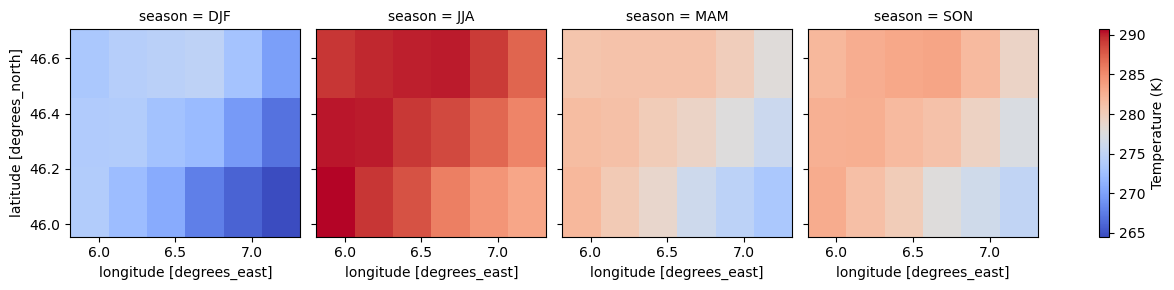

In [13]:
seasonal_means = ds['t2m'].groupby('valid_time.season').mean(dim='valid_time')

seasonal_means.plot(
    x='longitude', y='latitude', col='season', cmap='coolwarm',
    cbar_kwargs={'label': 'Temperature (K)'}
)

## Step 5: Seasonal maps in version 2

This version adds national borders to the seasonal maps.  
Including borders helps situate the data geographically and makes the plots more informative for regional analysis.

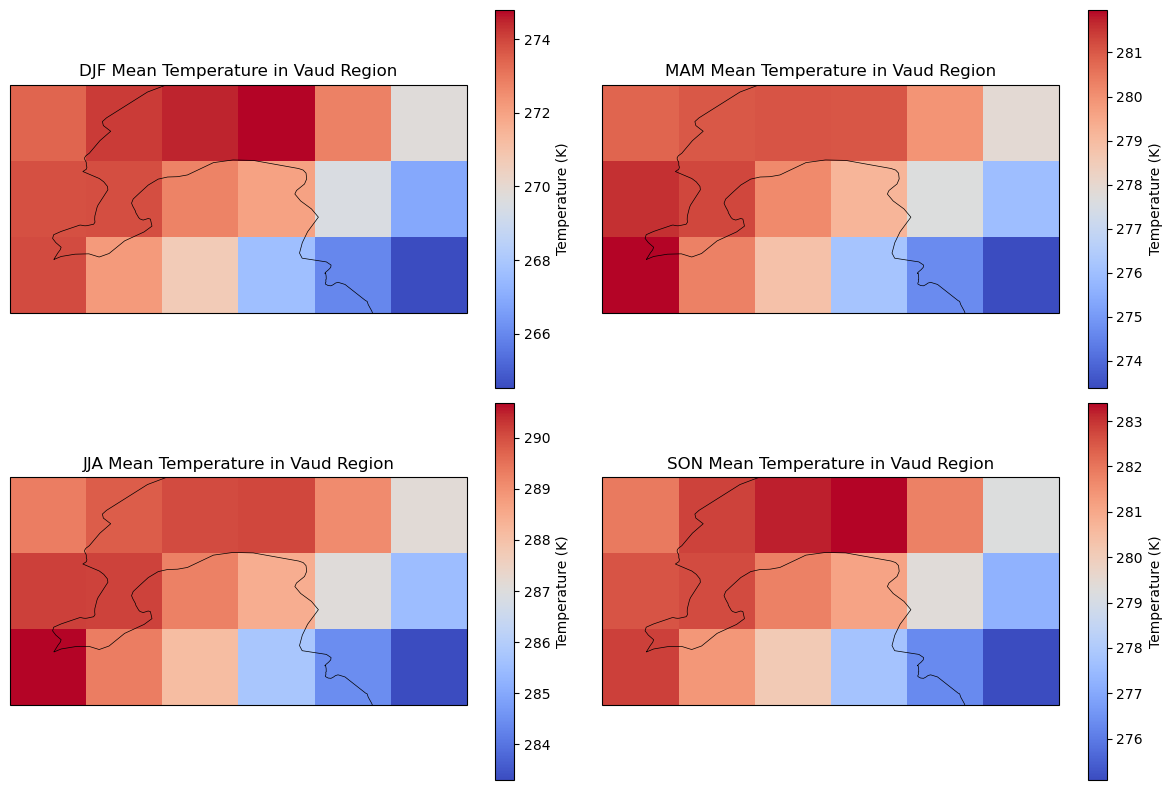

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
seasons = ['DJF', 'MAM', 'JJA', 'SON']

for ax, season in zip(axes.flat, seasons):
    seasonal_means.sel(season=season).plot(
        ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm',
        cbar_kwargs={'label': 'Temperature (K)'}
    )
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(f"{season} Mean Temperature in Vaud Region")

plt.tight_layout()
plt.show()

## Step 6: Seasonal maps in version 3

Final maps with:
- Lakes included for geographic context
- Celsius conversion (Kelvin → °C) for readability
- Latitude and longitude labels for orientation
- Consistent color scale across all seasons for comparability

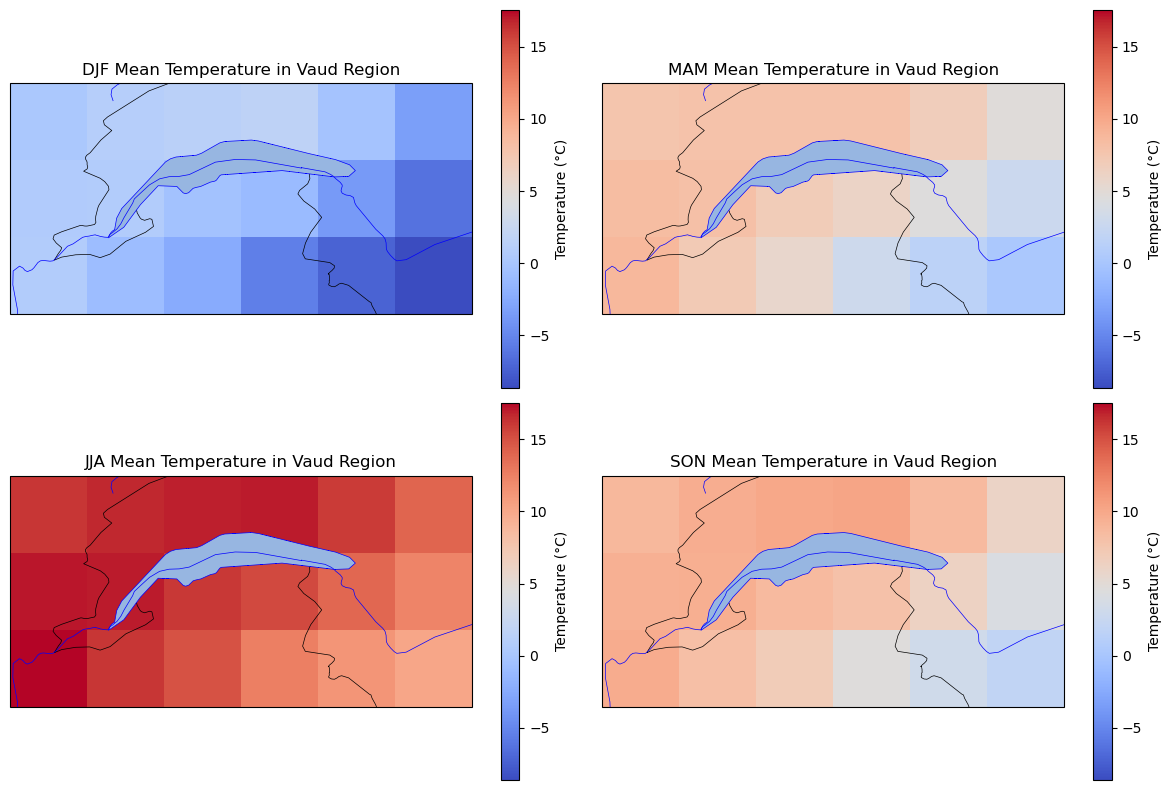

In [16]:
# Convert Kelvin to Celsius
ds_celsius = ds['t2m'] - 273.15
seasonal_means_c = ds_celsius.groupby('valid_time.season').mean(dim='valid_time')

# Consistent color scale
vmin = float(seasonal_means_c.min())
vmax = float(seasonal_means_c.max())

fig, axes = plt.subplots(2, 2, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
seasons = ['DJF', 'MAM', 'JJA', 'SON']

for ax, season in zip(axes.flat, seasons):
    seasonal_means_c.sel(season=season).plot(
        ax=ax, transform=ccrs.PlateCarree(),
        cmap='coolwarm', vmin=vmin, vmax=vmax,
        cbar_kwargs={'label': 'Temperature (°C)'}
    )
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAKES, linewidth=0.5, edgecolor='blue')
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')
    ax.set_title(f"{season} Mean Temperature in Vaud Region")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()